In [1]:
import numpy as np
import math as math
import matplotlib.pylab as plt
import matplotlib as mpl
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.tri as tri
import matplotlib.patches as mpatches
from scipy.special import factorial, gamma, digamma, ellipk, ellipe, hyp2f1
import mpmath as mp
from scipy.integrate import quad,trapezoid
from numpy import vectorize
from scipy.optimize import fsolve, bisect, newton

In [2]:
# Profiles
# n = 0:   NIS
# n = 3:   NFW
# n = 3.5: sNFW
# n = 4:   Hernquist

# Surface mass density (Simplified)
def SMDensity_sim(x, n, smd0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = smd0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
    #sNFW
    if n == 3.5:
        arg = (1-x)/(1+x)
        if x == 1:
            return smd0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return smd0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1-x)**2*(1 + x)**(3/2)))
        
    #Hernquist
    if n == 4:
        amp = smd0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return smd0*np.sqrt(np.pi)/np.sqrt(1 + x**2)

# Projected mass (Simplified)
def PMass_sim(x, n, r0, smd0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*np.sqrt(np.pi)*r0**2*smd0
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 + np.log(0.5))
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(np.log(0.5*x) + np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(np.log(0.5*x) + np.arccos(1/x)/arg)
    #sNFW
    if n == 3.5:
        amp = 2*np.pi*r0**2*smd0
        arg = (1 - x)/(1 + x)
        if x == 0:
            return 0.
        if x == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if x>0 and x != 1:
            return amp*(((ellipe(arg) - x*ellipk(arg))/(np.sqrt(1 + x)*(x - 1))) + 1)
    #Hernquist
    if n == 4:
        amp = 2*np.sqrt(np.pi)*r0**2*smd0
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x**2/(x**2 -1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x**2/(x**2 -1))*(1 - np.arccos(1/x)/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*(np.pi**1.5)*(r0**2)*smd0*(np.sqrt(1 + x**2) - 1)
    
# Deflection potential (Simplified)
def DPotential_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*np.log(2)**2
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*((np.log(0.5*x))**2 - (np.arccosh(1/x))**2)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*((np.log(0.5*x))**2 + (np.arccos(1/x))**2)
    #sNFW
    if n == 3.5:
        if x == 0:
            return 0
        if x > 0:
            arg = (1-x)/(1+x)
            return 2*(k0)*(2*ellipk(arg)/np.sqrt(1 + x) + np.log(x/8))
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(np.log(0.5*x) + np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(np.log(0.5*x) + np.arccos(1/x)/arg)

    #NIS
    if n == 0:
        return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - np.log(0.5*(np.sqrt(1 + x**2) + 1)) - 1)
        

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Convergence (Simplified)
def Convergence_sim(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return amp/3
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return amp*(1/(x**2 - 1))*(1 - np.arccosh(1/x)/arg)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return amp*(1/(x**2 - 1))*(1 - np.arccos(1/x)/arg)
            
    #sNFW
    if n == 3.5:
        arg = (1 - x)/(1 + x)
        if x == 1:
            return k0*9*np.pi/(128*np.sqrt(2))
        if x != 1:
            return k0*(((3 + x)*ellipk(arg) - 4*ellipe(arg))/(2*(1 - x)**2*(1 + x)**(3/2)))
            
        
    #Hernquist
    if n == 4:
        amp = k0/np.sqrt(np.pi)
        if x == 1: 
            return 4*amp/15
        if 0 < x < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccosh(1/x) - 3)
        if x > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/((x**2 - 1)**2))*(((2 + x**2)/(arg))*np.arccos(1/x) - 3)

    #NIS
    if n == 0:
        return k0*np.sqrt(np.pi)/np.sqrt(1 + x**2)


# Deflection angle (Simplified)
def DAngle_sim(x, n, k0):
    """
    x: dimensionless radius (position)
    n: profile
    k0: characteristic convergence
    """
    
    #NFW
    if n == 3:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp*(1 - np.log(2))
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1 - x**2)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp/x)*(np.log(0.5*np.abs(x)) + np.arccos(1/np.abs(x))/arg)
    #sNFW
    if n == 3.5:
        amp = 2*k0
        arg = (1 - np.abs(x))/(1 + np.abs(x))
        if x == 0:
            return 0.
        if np.abs(x) == 1:
            return amp*(1 - 3*np.pi/(8*np.sqrt(2)))
        if np.abs(x) > 0 and np.abs(x) != 1:
            return (amp/x)*(((ellipe(arg) - np.abs(x)*ellipk(arg))/(np.sqrt(1 + np.abs(x))*(np.abs(x) - 1))) + 1)
    
    #Hernquist
    if n == 4:
        amp = 2*k0/np.sqrt(np.pi)
        if x == 0:
            return 0
        if x == 1:
            return amp/3
        if 0 < np.abs(x) < 1:
            arg = np.sqrt(1. - x**2)
            return (amp*x/(x**2 - 1))*(1 - np.arccosh(1/np.abs(x))/arg)
        if np.abs(x) > 1:
            arg = np.sqrt(x**2 - 1)
            return (amp*x/(x**2 - 1))*(1 - np.arccos(1/np.abs(x))/arg)

    #NIS
    if n == 0:
        if x == 0:
            return 0
        else:
            return 2*np.sqrt(np.pi)*k0*(np.sqrt(1 + x**2) - 1)/x

# Shear (Simplified)
def Shear_sim(x, n, k0):
    """
    x >= 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    if x == 0 and n == 0:
        return 0
    if x == 0 and n != 0:
        return k0*gamma(n - 1)/(2*np.sqrt(np.pi))
    if x > 0:
        return DAngle_sim(x, n, k0)/x - Convergence_sim(x, n, k0)

# Mean shear (Simplified)
def MShear_sim(x, n, k0):
    """
    x >= 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    if x == 0 and n == 0:
        return 0
    if x == 0 and n != 0:
        return k0*gamma(n - 1)/(2*np.sqrt(np.pi))
    if x > 0:
        return 2*DPotential_sim(x, n, k0)/x**2 - DAngle_sim(x, n, k0)/x

# Magnification (Simplified)
def Magnification(x, n, k0):
    if x == 0 and n == 0:
        return 1/(1 - k0*np.sqrt(np.pi))**2
    if x == 0 and n != 0:
        return 0 
    if x > 0:
        return 1/((1 - Convergence_sim(x, n, k0))**2 - Shear_sim(x, n, k0)**2)
        
# Vectorized functions
smd_sim = vectorize(SMDensity_sim, otypes=[float], cache = True)
pm_sim = vectorize(PMass_sim, otypes=[float], cache = True)
dp_sim = vectorize(DPotential_sim, otypes=[float], cache = True)
da_sim = vectorize(DAngle_sim, otypes=[float], cache = True)
c_sim = vectorize(Convergence_sim, otypes=[float], cache = True)
s_sim = vectorize(Shear_sim, otypes=[float], cache = True)
ms_sim = vectorize(MShear_sim, otypes=[float], cache = True)
magnification = vectorize(Magnification, otypes=[float], cache = True)

In [3]:
# Equation for fincding the radial critical curve: RCC = 0
def RCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 + DAngle_sim(x, n, k0)/x - 2*Convergence_sim(x, n, k0)

# Equation for fincding the tangential critical curve: TCC = 0
def TCC(x, n, k0):
    """
    x > 0: dimensionless radius (position) 
    n: profile
    k0: characteristic convergence
    """
    return 1 - DAngle_sim(x, n, k0)/x
    
# Vectorized functions
tcc = vectorize(TCC, otypes=[float], cache = True)
rcc = vectorize(RCC, otypes=[float], cache = True)

In [4]:
def CCSolve(cri, crf, cti, ctf, N, RN, n, k0):
    """
    Here, we follow a similar process to the described in our paper (Sec. 5.2) for solving the lens equation. 
    
    For example, if we want to find the tangential critical curve, we take the domain (cti, ctf) and construct a one-dimensional grid
    with N nodes. Then, we evaluate the function TCC for that grid, such that the node for wich TCC is closest to zero corresponds to
    the tagential critical curve. Here, we can follow a refinement process which we repeat RN times. For RN = 1 we need N to be a
    relatively large number. However, if RN > 1, we can use a smaller N, and considering that the computed critical curve (approximately) 
    is the node x_i, the refinament process take the interval (x_(i-1), x_(i+1)) and construct the new grid, for which we repeat the 
    process. For the radial critical curve we follow the same process.
    
    (cri, crf): limits (they are both positive) within which we consider the critical radial curve is lolated
    (cti, ctf): limits (they are both positive) within which we consider the critical tangental curve is lolated
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: characteristic convergence
    """
    
    dx1 = np.abs(ctf - cti)/N
    dx2 = np.abs(crf - cri)/N
    x1 = np.linspace(cti, ctf, N)
    x2 = np.linspace(cri, crf, N)
    
    for i in range(RN):
        d1 = np.abs(tcc(x1, n, k0))
        d2 = np.abs(rcc(x2, n, k0))
        ind1 = np.where(d1 == np.amin(d1))[0][0]
        ind2 = np.where(d2 == np.amin(d2))[0][0]
        
        tan = x1[ind1]
        rad = x2[ind2]

        if tan - dx1 < 0:
            x1 = np.linspace(tan, tan + dx1, N)
        else:
            x1 = np.linspace(tan - dx1, tan + dx1, N)
        if rad - dx2 < 0:
            x2 = np.linspace(rad, rad + dx2, N)
        else:
            x2 = np.linspace(rad - dx2, rad + dx2, N)
        dx1 = 2*dx1/N
        dx2 = 2*dx2/N

        if np.abs(tcc(tan, n, k0)) <= 1e-15 and np.abs(rcc(rad, n, k0)) <= 1e-15:
            break

    return rad, tan

In [5]:
def critical_points(cri, crf, cti, ctf, N, RN, n, k0):
    """
    We start from the larger value, so that we can use its parame
    (cri, crf): initial limits for k0[-1] (they are both positive) within which we consider the critical radial curve is lolated
    (cti, ctf): initial limits for k0[-1] (they are both positive) within which we consider the critical tangental curve is lolated
    N: number of nodes 
    RN: how many times we oerform the refinement
    n: profile
    k0: list with the different characteristic convergences to evaluate
    """
    
    points = len(k0)

    xc2_list = np.zeros(points)
    xc1_list = np.zeros(points)
    yc2_list = np.zeros(points)

    for i in range(points):
        xc2, xc1 = CCSolve(cri, crf, cti, ctf, N, RN, n, k0[::-1][i])
        
        yc2 = np.abs(xc2 - da_sim(xc2, n, k0[::-1][i]))

        rc = np.abs(RCC(xc2, n, k0[::-1][i]))
        rt = np.abs(TCC(xc1, n, k0[::-1][i]))

        #Here. we verify that the critial and caustic curves, and xb are correct, within a certain degree.
        if np.any(np.array([rc, rt]) > 1e-6):
                print("Not good enough")
                print(k0[::-1][i], np.array([rc, rt]))
            
        xc2_list[::-1][i] = xc2
        xc1_list[::-1][i] = xc1
        yc2_list[::-1][i] = yc2

        # Restart the boundaries
        cri = 1e-10
        crf = 1.2*xc2
        cti = 1e-10
        ctf = 1.2*xc1 
        
    return xc2_list, xc1_list, yc2_list

### (3D) Mass distribution (profile) 

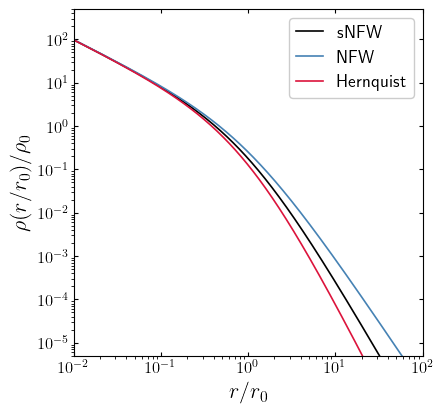

In [6]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(4.5,4.5))

ges = GridSpec(1, 1)

ax1 = fig.add_subplot(ges[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

x = np.linspace(0.001, 1000, 100000)

ax1.plot(x, 1/(x*(1 + x)**(2.5)), color =  color_snfw , linestyle = "-", label = r"sNFW", lw = lc)
ax1.plot(x, 1/(x*(1 + x)**(2)), color =  color_nfw , linestyle = "-", label = r"NFW", lw = lc)
ax1.plot(x, 1/(x*(1 + x)**(3)), color =  color_h , linestyle = "-", label = r"Hernquist", lw = lc)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$r/r_0$", fontsize=axis_fs)
ax1.set_ylabel(r"$\rho(r/r_0)/\rho_0$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
#ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0.01, 100)
ax1.set_ylim(5e-6, 500)
ax1.set_xscale("log")
ax1.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.legend(loc='upper right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("vmd.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### Surface mass density, projected mass, shear, and mean shear 

In [7]:
points = 100000
x = np.linspace(0.001, 1000, points)

# Surface mass density
smd_nfw = smd_sim(x, 3, 1)
smd_snfw = smd_sim(x, 3.5, 1)
smd_h = smd_sim(x, 4, 1)

# Projected mass
pm_nfw = pm_sim(x, 3, 1, 1)
pm_snfw = pm_sim(x, 3.5, 1, 1)
pm_h = pm_sim(x, 4, 1, 1)

# Shear
s_nfw = s_sim(x, 3, 1)
s_snfw = s_sim(x, 3.5, 1)
s_h = s_sim(x, 4, 1)

# Mean shear
ms_nfw = ms_sim(x, 3, 1)
ms_snfw = ms_sim(x, 3.5, 1)
ms_h = ms_sim(x, 4, 1)

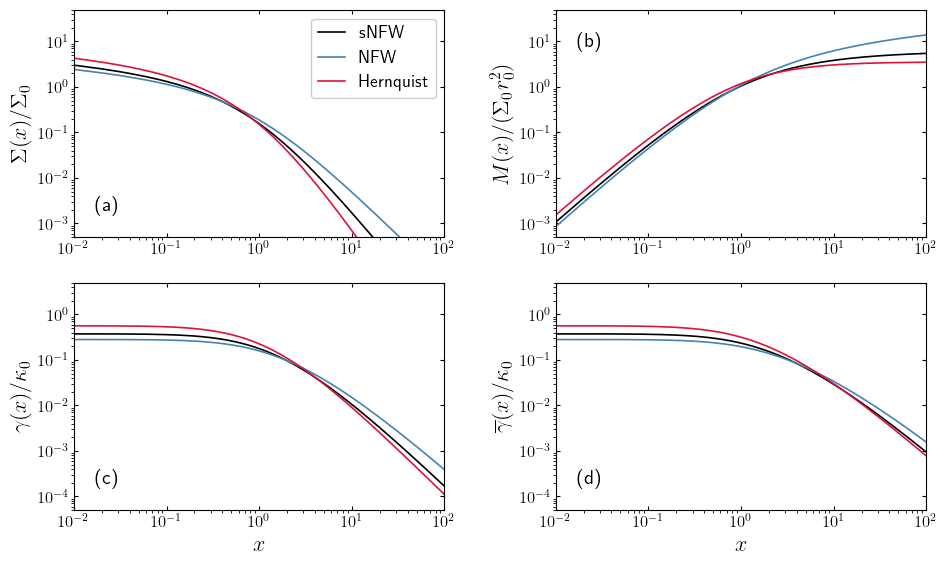

In [8]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(11,6.5))
#fig.suptitle(r"Controlling subplot sizes with width_ratios and height_ratios")

ges = GridSpec(2, 2,hspace=0.2, wspace=0.3)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[1,0])
ax4 = fig.add_subplot(ges[1,1])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

# Surface mass density
ax1.plot(x, smd_snfw, color =  color_snfw , linestyle = "-", label = r"sNFW", lw = lc)
ax1.plot(x, smd_nfw, color =  color_nfw , linestyle = "-", label = r"NFW", lw = lc)
ax1.plot(x, smd_h, color =  color_h , linestyle = "-", label = r"Hernquist", lw = lc)

# Projected mass
ax2.plot(x, pm_snfw, color =  color_snfw , linestyle = "-", label = r"sNFW", lw = lc)
ax2.plot(x, pm_nfw, color =  color_nfw , linestyle = "-", label = r"NFW", lw = lc)
ax2.plot(x, pm_h, color =  color_h , linestyle = "-", label = r"Hernquist", lw = lc)

# Shear
ax3.plot(x, s_snfw, color =  color_snfw , linestyle = "-", lw = lc)
ax3.plot(x, s_nfw, color =  color_nfw , linestyle = "-", lw = lc)
ax3.plot(x, s_h, color =  color_h , linestyle = "-", lw = lc)

# Mean shear
ax4.plot(x, ms_snfw, color =  color_snfw , linestyle = "-", label = r"sNFW", lw = lc)
ax4.plot(x, ms_nfw, color =  color_nfw , linestyle = "-", label = r"NFW", lw = lc)
ax4.plot(x, ms_h, color =  color_h , linestyle = "-", label = r"Hernquist", lw = lc)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$\Sigma(x)/\Sigma_0$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0.01, 100)
ax1.set_ylim(5e-4, 5e1)
ax1.set_xscale("log")
ax1.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

#ax2.set_xlabel(r"$x$", fontsize=axis_fs)
ax2.set_ylabel(r"$M(x)/(\Sigma_0 r_0^2)$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(0.01, 100)
ax2.set_ylim(5e-4, 5e1)
ax2.set_xscale("log")
ax2.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax3.set_xlabel(r"$x$", fontsize=axis_fs)
ax3.set_ylabel(r"$\gamma(x)/\kappa_0$", fontsize=axis_fs)
#ax3.set_title(r"$x$", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax3.set_xlim(0.01, 100)
ax3.set_ylim(5e-5, 5e0)
ax3.set_xscale("log")
ax3.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax4.set_xlabel(r"$x$", fontsize=axis_fs)
ax4.set_ylabel(r"$\overline{\gamma}(x)/\kappa_0$", fontsize=axis_fs)
#ax4.set_title(r"$x$", fontsize=axis_fs)
ax4.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
#ax3.set_xlim(0, 5)
#ax3.set_ylim(0, 0.6)
ax4.set_xlim(0.01, 100)
ax4.set_ylim(5e-5, 5e0)
ax4.set_xscale("log")
ax4.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.text(1.7e-2,1.5e-3, r"(a)", horizontalalignment="left", verticalalignment="bottom", fontsize = 0.9*axis_fs)
ax2.text(1.7e-2,1.6e1, r"(b)", horizontalalignment="left", verticalalignment="top", fontsize = 0.9*axis_fs)
ax3.text(1.7e-2,1.5e-4, r"(c)", horizontalalignment="left", verticalalignment="bottom", fontsize = 0.9*axis_fs)
ax4.text(1.7e-2,1.5e-4, r"(d)", horizontalalignment="left", verticalalignment="bottom", fontsize = 0.9*axis_fs)

ax1.legend(loc='upper right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
plt.savefig("comparison_smd_pm.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### Deflection angle and lens equation

In [9]:
x = np.linspace(-10, 10, 1000)

k0 = 3

# Deflection angle
da_nfw = da_sim(x, 3, 1)
da_snfw = da_sim(x, 3.5, 1)
da_h = da_sim(x, 4, 1)

# Derivative
da_der_nfw = 2*c_sim(np.abs(x), 3, 1) - da_nfw/x
da_der_snfw = 2*c_sim(np.abs(x), 3.5, 1) - da_snfw/x
da_der_h = 2*c_sim(np.abs(x), 4, 1) - da_h/x

# Lens equation
y_le_nfw = x - da_sim(x, 3, k0)
y_le_snfw = x - da_sim(x, 3.5, k0)
y_le_h = x - da_sim(x, 4, k0)

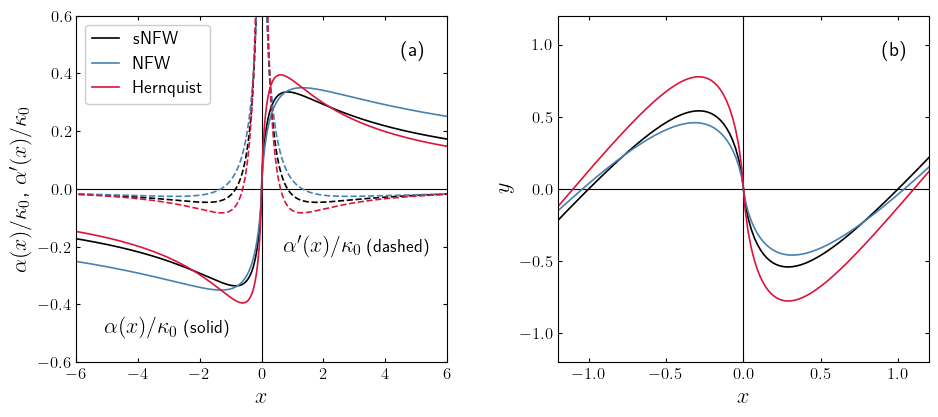

In [10]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(11, 4.5))

ges = GridSpec(1, 2,hspace=0., wspace=0.3)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.vlines(0, -100, 100, colors='k', linestyles='-', lw =0.8) # y axis
ax1.hlines(0, -100, 100, colors='k', linestyles='-', lw =0.8) # x axis

ax1.plot(x, da_snfw, color = color_snfw, linestyle = "-", linewidth = lc, label = r"sNFW") # Deflection angle 
ax1.plot(x, da_der_snfw, color =  color_snfw, linestyle = "--", linewidth = lc) # Derivative

ax1.plot(x, da_nfw, color = color_nfw, linestyle = "-", linewidth = lc, label = r"NFW") # Deflection angle
ax1.plot(x, da_der_nfw, color =  color_nfw, linestyle = "--", linewidth = lc) # Derivative

ax1.plot(x, da_h, color = color_h, linestyle = "-", linewidth = lc, label = r"Hernquist") # Deflection angle
ax1.plot(x, da_der_h, color =  color_h, linestyle = "--", linewidth = lc) # Derivative

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax2.vlines(0, -100, 100, colors='k', linestyles='-', lw =0.8) # y axis
ax2.hlines(0, -100, 100, colors='k', linestyles='-', lw =0.8) # x axis

# Lens equation
ax2.plot(x, y_le_snfw, color = color_snfw, linestyle = "-", linewidth = lc, label = r"sNFW")
ax2.plot(x, y_le_nfw, color = color_nfw, linestyle = "-", linewidth = lc, label = r"NFW")
ax2.plot(x, y_le_h, color = color_h, linestyle = "-", linewidth = lc, label = r"Hernquist")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$\alpha(x)/\kappa_0$, $\alpha^{\prime}(x)/\kappa_0$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.6,0.6)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax2.set_xlabel(r"$x$", fontsize=axis_fs)
ax2.set_ylabel(r"$y$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH


ax1.text(4.5,0.46, r"(a)", fontsize = 0.9*axis_fs)
ax2.text(0.9,0.92, r"(b)", fontsize = 0.9*axis_fs)

ax1.text(-5.1,-0.5, r"$\alpha(x)/\kappa_0$", fontsize = axis_fs)
ax1.text(0.7,-0.22, r"$\alpha^{\prime}(x)/\kappa_0$", fontsize = axis_fs)
ax1.text(-2.5,-0.5, r"(solid)", fontsize = 0.8*axis_fs)
ax1.text(3.4,-0.22, r"(dashed)", fontsize = 0.8*axis_fs)

ax1.legend(loc='upper left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("dangle_le.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

### Magnification

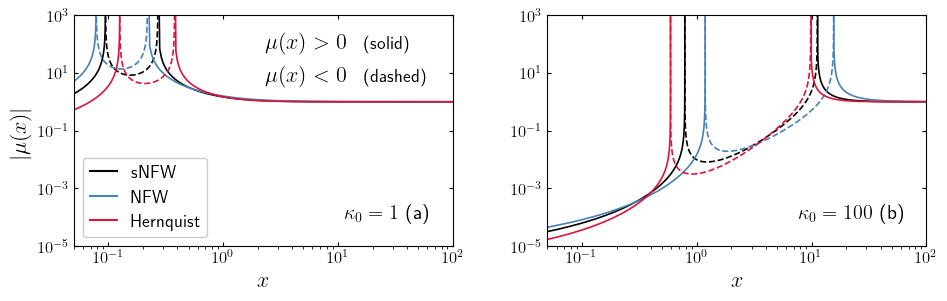

In [11]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

colors = [color_snfw, color_nfw, color_h]
models = [3.5, 3, 4]

fig = plt.figure(figsize=(11, 3))

ges = GridSpec(1, 2,hspace=0., wspace=0.25)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

k01 = 1
k02 = 100

points = 10000

# Panel (a)

for i in range(3):
    xc2, xc1 = CCSolve(1e-12, 50, 1e-12, 100, 1000, 10, models[i], k01)

    #Here, we verify that the critial curves  are correct
    #Ideally, |RCC| and |TCC| should be equal to zero
    rc = np.abs(RCC(xc2, models[i], k01))
    rt = np.abs(TCC(xc1, models[i], k01))
    if rc > 1e-8 or rt > 1e-8:
        print("Ups...")
        print("|RCC| =", rc)
        print("|TCC| =", rt)
        break
    
    x1 = np.linspace(0, 0.999999*xc2, points) # 0 < x < xc2
    x2 = np.linspace(1.000001*xc2, 0.999999*xc1, points) # xc2 < x <xc1
    x3 = np.linspace(1.000001*xc1, 100, points) # x > xc1

    ax1.plot(x1,  magnification(x1, models[i], k01), color = colors[i], linestyle = "-", lw = lc)
    ax1.plot(x2,  np.abs(magnification(x2, models[i], k01)), color = colors[i], linestyle = "--", lw = lc)
    ax1.plot(x3,  magnification(x3, models[i], k01), color = colors[i], linestyle = "-", lw = lc)

# Panel (b)

for i in range(3):
    xc2, xc1 = CCSolve(1e-12, 50, 1e-12, 500, 1000, 10, models[i], k02)

    #Here, we verify that the critial curves  are correct
    #Ideally, |RCC| and |TCC| should be equal to zero
    rc = np.abs(RCC(xc2, models[i], k02))
    rt = np.abs(TCC(xc1, models[i], k02))
    if rc > 1e-8 or rt > 1e-8:
        print("Ups...")
        print("|RCC| =", rc)
        print("|TCC| =", rt)
        break
    
    x1 = np.linspace(0, 0.9999999*xc2, points) # 0 < x < xc2
    x2 = np.linspace(1.0000001*xc2, 0.9999999*xc1, points) # xc2 < x <xc1
    x3 = np.linspace(1.0000001*xc1, 1000, points) # x > xc1

    ax2.plot(x1,  magnification(x1, models[i], k02), color = colors[i], linestyle = "-", lw = lc)
    ax2.plot(x2,  np.abs(magnification(x2, models[i], k02)), color = colors[i], linestyle = "--", lw = lc)
    ax2.plot(x3,  magnification(x3, models[i], k02), color = colors[i], linestyle = "-", lw = lc)


#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$|\mu(x)|$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.3))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.set_xlim(0.05, 100)
ax1.set_ylim(1e-5, 1000)
ax1.set_xscale("log")
ax1.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax2.set_xlabel(r"$x$", fontsize=axis_fs)
#ax2.set_ylabel(r"$y$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
#ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.3))
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.set_xlim(0.05, 100)
ax2.set_ylim(1e-5, 1000)
ax2.set_xscale("log")
ax2.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.text(65,3e-4, r"$\kappa_0=1$ (a)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)
ax2.text(65,3e-4, r"$\kappa_0=100$ (b)", horizontalalignment="right", verticalalignment="top", fontsize = 0.9*axis_fs)

ax1.text(12,70, r"$\mu(x)>0$", horizontalalignment="right", fontsize = axis_fs)
ax1.text(12,5, r"$\mu(x)<0$", horizontalalignment="right", fontsize = axis_fs)
ax1.text(17,70, r"(solid)", fontsize = 0.8*axis_fs)
ax1.text(17, 5, r"(dashed)", fontsize = 0.8*axis_fs)

ax1.plot([], [], color = color_snfw, linestyle = "-", label = r"sNFW")
ax1.plot([], [], color = color_nfw, linestyle = "-", label = r"NFW")
ax1.plot([], [], color = color_h, linestyle = "-", label = r"Hernquist")

ax1.legend(loc='lower left', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

plt.savefig("mag.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()


### Critical and caustic curves as a function of $\kappa_0$


In [12]:
points = 500
N = 1000
RN = 5
k0_max = 15
k0 = np.linspace(0.1, k0_max, points)

n_nfw = 3
n_snfw = 3.5
n_h = 4

In [13]:
# Here, we find the initial values, wich are obtained form those of k0_max
crs_nfw, cts_nfw = CCSolve(0.3, 2, 1, 30, 100, 10, n_nfw, k0_max)
print("Radial = ", crs_nfw)
print("Tangential = ", cts_nfw)
print("|RCC| =", np.abs(RCC(crs_nfw, n_nfw, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts_nfw, n_nfw, k0_max))) # Ideally, it should be equal to zero

Radial =  0.7940800132169941
Tangential =  4.277956741371042
|RCC| = 0.0
|TCC| = 0.0


In [14]:
xc2_nfw, xc1_nfw, yc2_nfw = critical_points(0.8*crs_nfw, 1.2*crs_nfw, 0.8*cts_nfw, 1.2*cts_nfw, N, RN, n_nfw, k0)

In [15]:
# Here, we find the initial values, wich are obtained form those of k0_max
crs_snfw, cts_snfw = CCSolve(0.3, 2, 1, 30, 100, 10, n_snfw, k0_max)
print("Radial = ", crs_snfw)
print("Tangential = ", cts_snfw)
print("|RCC| =", np.abs(RCC(crs_snfw, n_snfw, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts_snfw, n_snfw, k0_max))) # Ideally, it should be equal to zero

Radial =  0.5974400604024128
Tangential =  3.5002356307188442
|RCC| = 0.0
|TCC| = 4.440892098500626e-16


In [16]:
xc2_snfw, xc1_snfw, yc2_snfw = critical_points(0.8*crs_snfw, 1.2*crs_snfw, 0.8*cts_snfw, 1.2*cts_snfw, N, RN, n_snfw, k0)

In [17]:
# Here, we find the initial values, wich are obtained form those of k0_max
crs_h, cts_h = CCSolve(0.3, 2, 1, 30, 100, 10, n_h, k0_max)
print("Radial = ", crs_h)
print("Tangential = ", cts_h)
print("|RCC| =", np.abs(RCC(crs_h, n_h, k0_max))) # Ideally, it should be equal to zero
print("|TCC| =", np.abs(TCC(cts_h, n_h, k0_max))) # Ideally, it should be equal to zero

Radial =  0.49390873376749506
Tangential =  3.348478568736191
|RCC| = 0.0
|TCC| = 4.440892098500626e-16


In [18]:
xc2_h, xc1_h, yc2_h = critical_points(0.8*crs_h, 1.2*crs_h, 0.8*cts_h, 1.2*cts_h, N, RN, n_h, k0)

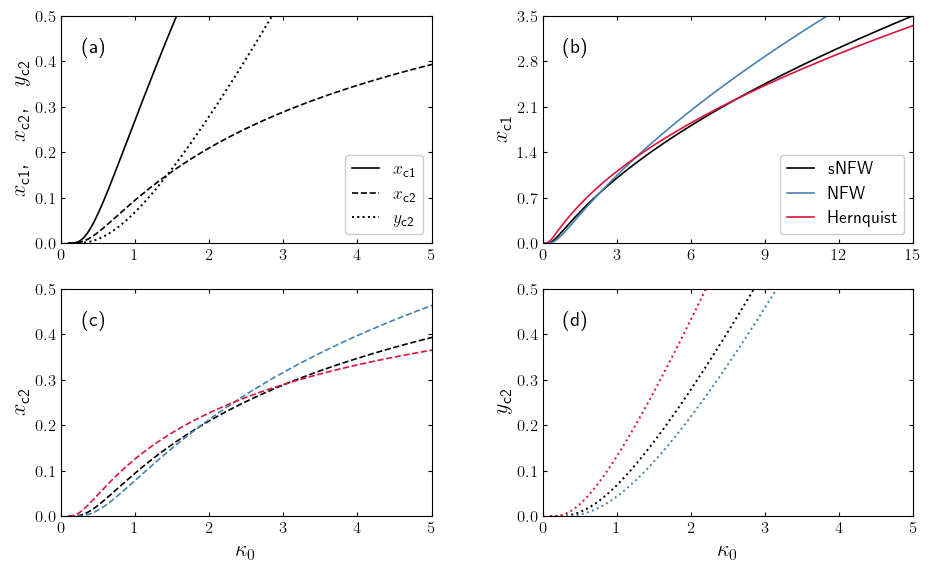

In [19]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12

lc = 1.2

color_snfw = "black"
color_nfw = "steelblue"
color_h = "crimson"

fig = plt.figure(figsize=(11,6.5))

ges = GridSpec(2, 2,hspace=0.2, wspace=0.3)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[1,0])
ax4 = fig.add_subplot(ges[1,1])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Curves
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(k0, xc1_snfw, color = color_snfw, linestyle = "-", label = r"$x_{\text{c1}}$", lw = lc)
ax1.plot(k0, xc2_snfw, color = color_snfw, linestyle = "--", label = r"$x_{\text{c2}}$", lw = lc)
ax1.plot(k0, yc2_snfw, color = color_snfw, linestyle = ":", label = r"$y_{\text{c2}}$", lw = 1.2*lc)

ax2.plot(k0, xc1_snfw, color = color_snfw, linestyle = "-", label = r"sNFW", lw = lc)
ax2.plot(k0, xc1_nfw, color = color_nfw, linestyle = "-", label = r"NFW", lw = lc)
ax2.plot(k0, xc1_h, color = color_h, linestyle = "-", label = r"Hernquist", lw = lc)

ax3.plot(k0, xc2_snfw, color = color_snfw, linestyle = "--", lw = lc)
ax3.plot(k0, xc2_nfw, color = color_nfw, linestyle = "--", lw = lc)
ax3.plot(k0, xc2_h, color = color_h, linestyle = "--", lw = lc)

ax4.plot(k0, yc2_snfw, color = color_snfw, linestyle = ":", lw = 1.2*lc)
ax4.plot(k0, yc2_nfw, color = color_nfw, linestyle = ":", lw = 1.2*lc)
ax4.plot(k0, yc2_h, color = color_h, linestyle = ":", lw = 1.2*lc)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Axes parameters
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$x_{\text{c1}}$,\quad $x_{\text{c2}}$,\quad $y_{\text{c2}}$", fontsize=axis_fs)
#ax1.set_title(r"$x$", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.set_xlim(0, 5)
ax1.set_ylim(0, 0.5)
#ax1.set_xscale("log")
#ax1.set_yscale("log")

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhH

#ax2.set_xlabel(r"$x$", fontsize=axis_fs)
ax2.set_ylabel(r"$x_{\text{c1}}$", fontsize=axis_fs)
#ax2.set_title(r"$x$", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(3))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 3.5)


#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax3.set_ylabel(r"$x_{\text{c2}}$", fontsize=axis_fs)
ax3.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax3.set_title(r"$x$", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax3.set_xlim(0, 5)
ax3.set_ylim(0, 0.5)

#hhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh

ax4.set_ylabel(r"$y_{\text{c2}}$", fontsize=axis_fs)
ax4.set_xlabel(r"$\kappa_0$", fontsize=axis_fs)
#ax4.set_title(r"$x$", fontsize=axis_fs)
ax4.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax4.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax4.set_xlim(0, 5)
ax4.set_ylim(0, 0.5)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Text and legend
#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.text(0.28,0.45, r"(a)",  horizontalalignment="left", verticalalignment="top", fontsize = 0.9*axis_fs)
ax2.text(3*0.28,7*0.45, r"(b)",  horizontalalignment="left", verticalalignment="top", fontsize = 0.9*axis_fs)
ax3.text(0.28,0.45, r"(c)",  horizontalalignment="left", verticalalignment="top",fontsize = 0.9*axis_fs)
ax4.text(0.28,0.45, r"(d)",  horizontalalignment="left", verticalalignment="top", fontsize = 0.9*axis_fs)

ax1.legend(loc='lower right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)
ax2.legend(loc='lower right', framealpha = 1, fontsize = 0.8*axis_fs, handlelength = 1.5)

plt.savefig("cc.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()